# TMDB Movie Data Analysis using Pandas and APIs

## Project Overview
This project builds a complete data pipeline to analyze movie performance using TMDb API data.

### Objectives:
- Extract data from API
- Clean and transform dataset
- Compute KPIs (Revenue, Profit, ROI, etc.)
- Perform advanced filtering
- Analyze franchises and directors
- Visualize insights


In [1]:
# import libraries
import requests
import pandas as pd
import numpy as np
import json
import time
import os
import seaborn as sns
import matplotlib.pyplot as plt
from dotenv import load_dotenv


In [2]:
load_dotenv()
API_KEY = os.getenv("TMDB_API_KEY")

if not API_KEY:
    raise ValueError("API key not found. Please set TMDB_API_KEY in .env file.")

In [3]:
movie_ids = [299534, 19995, 140607, 299536, 597, 135397,
             420818, 24428, 168259, 99861, 284054, 12445,
             181808, 330457, 351286, 109445, 321612, 260513]

In [4]:
def fetch_movie(movie_id):
    url = f"https://api.themoviedb.org/3/movie/{movie_id}?api_key={API_KEY}&append_to_response=credits"

    for attempt in range(3):
        try:
            response = requests.get(url, timeout=10)

            if response.status_code == 200:
                return response.json()
            else:
                print(f"Warning: {movie_id} failed with {response.status_code}")

        except requests.exceptions.RequestException as e:
            print(f"Error fetching {movie_id}: {e}")

        time.sleep(2 ** attempt)

    return None

In [5]:
movies = []
errors = []

for mid in movie_ids:
    data = fetch_movie(mid)

    if data:
        movies.append(data)
    else:
        errors.append(mid)

df_raw = pd.DataFrame(movies)

print("Fetched movies:", len(df_raw))
print("Failed IDs:", errors)

df_raw.head()

Fetched movies: 18
Failed IDs: []


,adult,backdrop_path,belongs_to_collection,budget,genres,homepage,id,imdb_id,origin_country,original_language,...,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count,credits
0,False,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",356000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 878, ...",https://www.marvel.com/movies/avengers-endgame,299534,tt4154796,[US],en,...,2799439100,181,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Avenge the fallen.,Avengers: Endgame,False,8.234,27500,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
1,False,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,"{'id': 87096, 'name': 'Avatar Collection', 'po...",237000000,"[{'id': 878, 'name': 'Science Fiction'}, {'id'...",https://www.avatar.com/movies/avatar,19995,tt0499549,[US],en,...,2923706026,162,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Enter the world of Pandora.,Avatar,False,7.602,33780,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
2,False,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,"{'id': 10, 'name': 'Star Wars Collection', 'po...",245000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",http://www.starwars.com/films/star-wars-episod...,140607,tt2488496,[US],en,...,2068223624,136,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Every generation has a story.,Star Wars: The Force Awakens,False,7.250,20432,"{'cast': [{'adult': False, 'gender': 1, 'id': ..."
3,False,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,"{'id': 86311, 'name': 'The Avengers Collection...",300000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 28, '...",https://www.marvel.com/movies/avengers-infinit...,299536,tt4154756,[US],en,...,2052415039,149,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Destiny arrives all the same.,Avengers: Infinity War,False,8.234,31741,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."
4,False,/qBChUbS8ksbJoPTfZpogsnxG5tY.jpg,None,200000000,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",https://www.paramountmovies.com/movies/titanic,597,tt0120338,[US],en,...,2264162353,194,"[{'english_name': 'English', 'iso_639_1': 'en'...",Released,Nothing on earth could come between them.,Titanic,False,7.902,26996,"{'cast': [{'adult': False, 'gender': 2, 'id': ..."


In [6]:
df = df_raw.copy()

df.drop(columns=['adult', 'imdb_id', 'original_title', 'video', 'homepage'],
        errors='ignore', inplace=True)

In [7]:
def extract_pipe_names(x):
    if isinstance(x, list):
        return "|".join([i.get("name") for i in x if i.get("name")])
    return "UNKNOWN"

df['genres'] = df['genres'].apply(extract_pipe_names)
df['production_companies'] = df['production_companies'].apply(extract_pipe_names)
df['production_countries'] = df['production_countries'].apply(extract_pipe_names)
df['spoken_languages'] = df['spoken_languages'].apply(extract_pipe_names)

In [8]:
def extract_collection(x):
    if isinstance(x, dict):
        return x.get("name")
    return "UNKNOWN"

df['belongs_to_collection'] = df['belongs_to_collection'].apply(extract_collection)

In [9]:
def extract_credits(x):
    if not isinstance(x, dict):
        return pd.Series(["UNKNOWN", 0, "UNKNOWN", 0])

    cast = x.get("cast", [])
    crew = x.get("crew", [])

    cast_names = "|".join([c.get("name") for c in cast[:10] if c.get("name")])
    director = next((c.get("name") for c in crew if c.get("job") == "Director"), "UNKNOWN")

    return pd.Series([cast_names, len(cast), director, len(crew)])

df[['cast', 'cast_size', 'director', 'crew_size']] = df['credits'].apply(extract_credits)
df.drop(columns=['credits'], inplace=True)

In [10]:
numeric_cols = ['budget', 'revenue', 'runtime', 'popularity', 'vote_count', 'vote_average']

for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

In [11]:
df.loc[df['budget'] <= 0, 'budget'] = np.nan
df.loc[df['revenue'] <= 0, 'revenue'] = np.nan
df.loc[df['runtime'] <= 0, 'runtime'] = np.nan

In [12]:
df['budget_musd'] = df['budget'] / 1_000_000
df['revenue_musd'] = df['revenue'] / 1_000_000
df['profit_musd'] = df['revenue_musd'] - df['budget_musd']
df['roi'] = df['revenue_musd'] / df['budget_musd']

In [13]:
# --- Fix list columns ---
df['origin_country'] = df['origin_country'].apply(
    lambda x: "|".join(x) if isinstance(x, list) else x
)

# --- Final cleaning ---
if 'status' in df.columns:
    df = df[df['status'] == 'Released']
    df.drop(columns=['status'], inplace=True, errors='ignore')

df.drop_duplicates(subset=['id'], inplace=True)
df.dropna(subset=['id', 'title'], inplace=True)

df.reset_index(drop=True, inplace=True)

df.head()

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,vote_average,vote_count,cast,cast_size,director,crew_size,budget_musd,revenue_musd,profit_musd,roi
0,/7RyHsO4yDXtBv1zUU3mTpHeQ0d5.jpg,The Avengers Collection,356000000.0,Adventure|Science Fiction|Action,299534,US,en,After the devastating events of Avengers: Infi...,32.5723,/ulzhLuWrPK07P1YkdWQLZnQh1JL.jpg,...,8.234,27500,Robert Downey Jr.|Chris Evans|Mark Ruffalo|Chr...,104,Joe Russo,611,356.0,2799.439100,2443.439100,7.863593
1,/vL5LR6WdxWPjLPFRLe133jXWsh5.jpg,Avatar Collection,237000000.0,Science Fiction|Action|Adventure,19995,US,en,"In the 22nd century, a paraplegic Marine is di...",33.3375,/gKY6q7SjCkAU6FqvqWybDYgUKIF.jpg,...,7.602,33780,Sam Worthington|Zoe Saldaña|Sigourney Weaver|S...,67,James Cameron,999,237.0,2923.706026,2686.706026,12.336312
2,/8BTsTfln4jlQrLXUBquXJ0ASQy9.jpg,Star Wars Collection,245000000.0,Adventure|Action|Science Fiction,140607,US,en,Thirty years after defeating the Galactic Empi...,11.3676,/wqnLdwVXoBjKibFRR5U3y0aDUhs.jpg,...,7.250,20432,Daisy Ridley|John Boyega|Oscar Isaac|Adam Driv...,99,J.J. Abrams,264,245.0,2068.223624,1823.223624,8.441729
3,/mDfJG3LC3Dqb67AZ52x3Z0jU0uB.jpg,The Avengers Collection,300000000.0,Adventure|Action|Science Fiction,299536,US,en,As the Avengers and their allies have continue...,42.7418,/7WsyChQLEftFiDOVTGkv3hFpyyt.jpg,...,8.234,31741,Robert Downey Jr.|Chris Evans|Chris Hemsworth|...,69,Joe Russo,732,300.0,2052.415039,1752.415039,6.841383
4,/qBChUbS8ksbJoPTfZpogsnxG5tY.jpg,UNKNOWN,200000000.0,Drama|Romance,597,US,en,101-year-old Rose DeWitt Bukater tells the sto...,29.8274,/9xjZS2rlVxm8SFx8kPC3aIGCOYQ.jpg,...,7.902,26996,Leonardo DiCaprio|Kate Winslet|Billy Zane|Kath...,116,James Cameron,264,200.0,2264.162353,2064.162353,11.320812


In [14]:
def rank_movies(df, column, ascending=False, n=10):
    return df.dropna(subset=[column]).sort_values(column, ascending=ascending)[['title', column]].head(n)

In [15]:
rank_movies(df, 'revenue_musd')

,title,revenue_musd
1,Avatar,2923.706026
0,Avengers: Endgame,2799.439100
4,Titanic,2264.162353
2,Star Wars: The Force Awakens,2068.223624
3,Avengers: Infinity War,2052.415039
5,Jurassic World,1671.537444
6,The Lion King,1662.020819
7,The Avengers,1518.815515
8,Furious 7,1515.400000
13,Frozen II,1453.683476


In [16]:
rank_movies(df, 'profit_musd')

,title,profit_musd
1,Avatar,2686.706026
0,Avengers: Endgame,2443.439100
4,Titanic,2064.162353
2,Star Wars: The Force Awakens,1823.223624
3,Avengers: Infinity War,1752.415039
5,Jurassic World,1521.537444
6,The Lion King,1402.020819
8,Furious 7,1325.400000
13,Frozen II,1303.683476
7,The Avengers,1298.815515


In [17]:
df_roi = df[df['budget_musd'] >= 10]
rank_movies(df_roi, 'roi')

,title,roi
1,Avatar,12.336312
4,Titanic,11.320812
5,Jurassic World,11.143583
11,Harry Potter and the Deathly Hallows: Part 2,10.732090
13,Frozen II,9.691223
15,Frozen,8.494793
2,Star Wars: The Force Awakens,8.441729
8,Furious 7,7.975789
16,Beauty and the Beast,7.913225
0,Avengers: Endgame,7.863593


In [18]:
df[
    df['genres'].str.contains("Science Fiction", case=False, na=False) &
    df['genres'].str.contains("Action", case=False, na=False) &
    df['cast'].str.contains("Bruce Willis", case=False, na=False)
].sort_values('vote_average', ascending=False)

,backdrop_path,belongs_to_collection,budget,genres,id,origin_country,original_language,overview,popularity,poster_path,...,vote_average,vote_count,cast,cast_size,director,crew_size,budget_musd,revenue_musd,profit_musd,roi


In [19]:
df['is_franchise'] = df['belongs_to_collection'] != "UNKNOWN"

df.groupby('is_franchise').agg(
    mean_revenue=('revenue_musd', 'mean'),
    median_roi=('roi', 'median'),
    mean_budget=('budget_musd', 'mean'),
    mean_popularity=('popularity', 'mean'),
    mean_rating=('vote_average', 'mean')
)

,mean_revenue,median_roi,mean_budget,mean_popularity,mean_rating
is_franchise,,,,,
False,1765.139159,9.617018,180.0,19.816550,7.451000
True,1682.668411,7.786117,218.0,21.658569,7.390625


## Data visualization

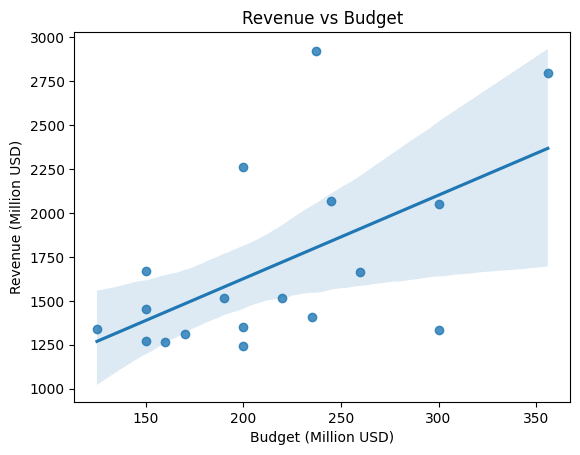

In [20]:
sns.regplot(data=df, x='budget_musd', y='revenue_musd')
plt.title("Revenue vs Budget")
plt.xlabel("Budget (Million USD)")
plt.ylabel("Revenue (Million USD)")
plt.show()

There is a clear positive relationship between budget and revenue, indicating that higher-budget movies tend to generate higher earnings. However, the spread of data points shows that high investment does not always guarantee proportional returns, highlighting variability in financial performance.

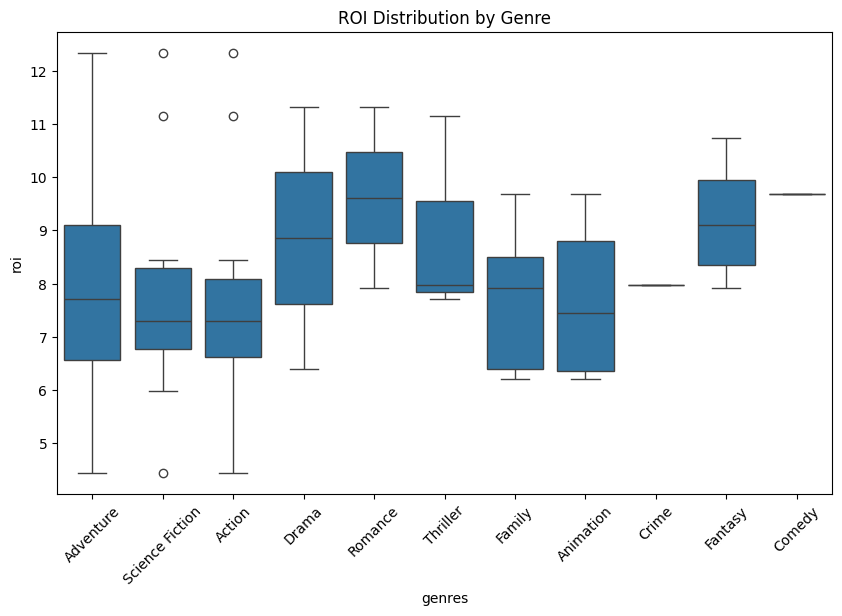

In [21]:
df_exploded = df.assign(genres=df['genres'].str.split('|')).explode('genres')

plt.figure(figsize=(10,6))
sns.boxplot(data=df_exploded, x='genres', y='roi')
plt.xticks(rotation=45)
plt.title("ROI Distribution by Genre")
plt.show()

ROI varies significantly across genres, with some genres such as Drama and Romance showing higher median returns, while others like Action and Science Fiction exhibit wider variability. This suggests that certain genres may offer more consistent profitability, while others carry higher financial risk.

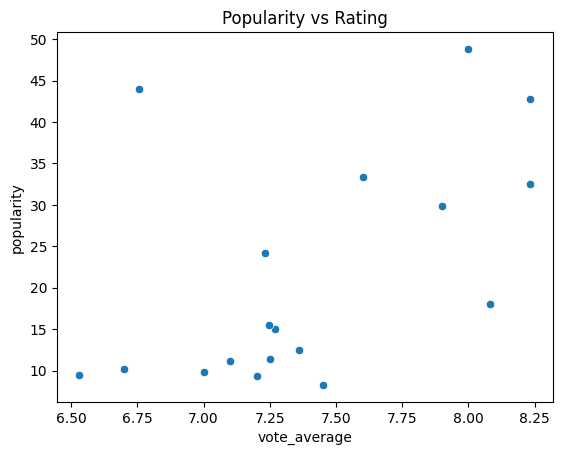

In [22]:
sns.scatterplot(data=df, x='vote_average', y='popularity')
plt.title("Popularity vs Rating")
plt.show()

There is a weak positive relationship between popularity and vote average, indicating that higher-rated movies tend to be somewhat more popular. However, the scatter shows considerable dispersion, suggesting that popularity is influenced by additional factors beyond ratings, such as marketing and franchise recognition.

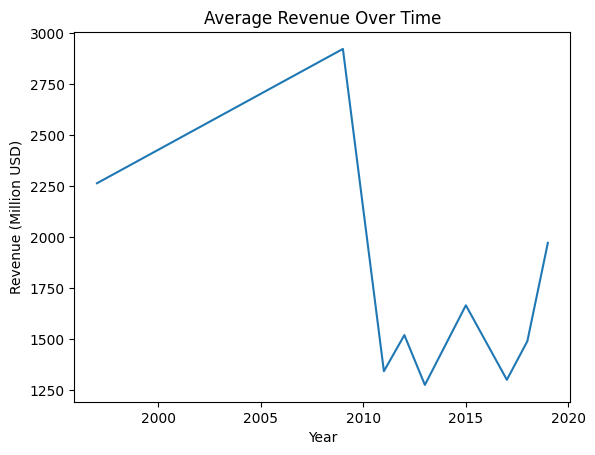

In [23]:
df['year'] = pd.to_datetime(df['release_date'], errors='coerce').dt.year
df_year = df.groupby('year')['revenue_musd'].mean().reset_index()

sns.lineplot(data=df_year, x='year', y='revenue_musd')
plt.title("Average Revenue Over Time")
plt.xlabel("Year")
plt.ylabel("Revenue (Million USD)")
plt.show()

Average movie revenue fluctuates across years, with noticeable peaks driven by blockbuster releases. This indicates that overall yearly performance is heavily influenced by a few high-grossing films rather than a steady upward trend in revenue.



- Higher budget movies generally generate higher revenue, though returns are not always proportional.
- ROI varies widely across genres, reflecting differences in production costs and audience demand.
- Franchise films tend to show more stable and predictable performance compared to standalone movies.
- Popularity and ratings are positively related but not strongly correlated, indicating multiple drivers of audience engagement.
- Revenue trends over time are inconsistent and often driven by blockbuster films rather than gradual growth.